In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

# ── 1. Loading NASA PM2.5 data ───────────────────────────────────────────────────
tif_path = r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif"
img = Image.open(tif_path)

# Croping to India
img_width, img_height = img.size
lon_min_global, lat_max_global = -180, 90
india_lon_min, india_lon_max = 68.0, 97.5
india_lat_min, india_lat_max = 8.0, 37.5

def lon_to_col(lon):
    return int((lon - lon_min_global) / 360 * img_width)

def lat_to_row(lat):
    return int((lat_max_global - lat) / 180 * img_height)

col_start = lon_to_col(india_lon_min)
col_end   = lon_to_col(india_lon_max)
row_start = lat_to_row(india_lat_max)
row_end   = lat_to_row(india_lat_min)

india_crop = img.crop((col_start, row_start, col_end, row_end))
pm25_array = np.array(india_crop, dtype=np.float32)
pm25_array[pm25_array <= 0] = np.nan

pixel_size_lon = (india_lon_max - india_lon_min) / pm25_array.shape[1]
pixel_size_lat = (india_lat_max - india_lat_min) / pm25_array.shape[0]

print(f"PM2.5 array loaded: {pm25_array.shape}")
print(f"Mean PM2.5: {np.nanmean(pm25_array):.2f} µg/m³")

# ── 2. Loading district shapefile and census ─────────────────────────────────────
india = gpd.read_file("https://github.com/datameet/maps/raw/master/Districts/Census_2011/2011_Dist.shp")
url   = "https://raw.githubusercontent.com/nishusharma1608/India-Census-2011-Analysis/master/india-districts-census-2011.csv"
df_census = pd.read_csv(url)

# ── 3. Sampling PM2.5 at each district centroid ─────────────────────────────────
def get_pm25(lon, lat):
    if not (india_lon_min <= lon <= india_lon_max and india_lat_min <= lat <= india_lat_max):
        return np.nan
    col = int((lon - india_lon_min) / pixel_size_lon)
    row = int((india_lat_max - lat) / pixel_size_lat)
    row = min(row, pm25_array.shape[0] - 1)
    col = min(col, pm25_array.shape[1] - 1)
    return float(pm25_array[row, col])

india['centroid_lon'] = india.geometry.centroid.x
india['centroid_lat'] = india.geometry.centroid.y
india['PM25']         = india.apply(lambda r: get_pm25(r['centroid_lon'], r['centroid_lat']), axis=1)

print(f"Districts with PM2.5: {india['PM25'].notna().sum()}")

PM2.5 array loaded: (2049, 2950)
Mean PM2.5: 44.18 µg/m³
Districts with PM2.5: 634


C:\Users\Arshia4\AppData\Local\Temp\ipykernel_33612\222217587.py:54: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india['centroid_lon'] = india.geometry.centroid.x
C:\Users\Arshia4\AppData\Local\Temp\ipykernel_33612\222217587.py:55: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india['centroid_lat'] = india.geometry.centroid.y


In [5]:
# ── 4. Merging census data ──────────────────────────────────────────────────────
india_clean   = india.copy()
census_clean  = df_census.copy()

india_clean['District_clean']  = india_clean['DISTRICT'].str.strip().str.title()
census_clean['District_clean'] = census_clean['District name'].str.strip().str.title()

df = india_clean[['District_clean', 'ST_NM', 'PM25']].merge(
    census_clean[['District_clean', 'Population', 'Workers',
                  'Agricultural_Workers',
                  'Power_Parity_Less_than_Rs_45000',
                  'Total_Power_Parity']],
    on='District_clean', how='inner').dropna()

df['Agri_Share']   = df['Agricultural_Workers'] / df['Workers'] * 100
df['Poverty_Rate'] = df['Power_Parity_Less_than_Rs_45000'] / df['Total_Power_Parity'] * 100

print(f"Districts in model: {len(df)}")

# ── 5. Cobb-Douglas parameters ──────────────────
# Agriculture sector: α = 0.35 (capital), β = 0.65 (labour)
alpha_agri = 0.35
beta_agri  = 0.65

# WHO interim target 3 = 15 µg/m³ (Scenario B)
# WHO 2021 actual guideline = 5 µg/m³
WHO_INTERIM = 15.0
WHO_STRICT  = 5.0

# ── 6. Damage functions ───────────────────────────────────────────────────────
# These scale ΔK/K and ΔL/L linearly with PM2.5 above the safe threshold
# At mean IGP PM2.5 (~80 µg/m³): ΔK/K = 11%, ΔL/L = 5%
# We scale proportionally so every district gets its own damage estimate

IGP_MEAN_PM25 = 80.0  # approximate mean PM2.5 in Indo-Gangetic Plain

def delta_K(pm25, threshold=WHO_INTERIM):
    """Capital damage rate, scales with excess PM2.5 above threshold"""
    excess = max(pm25 - threshold, 0)
    igp_excess = IGP_MEAN_PM25 - threshold
    return 0.11 * (excess / igp_excess) if igp_excess > 0 else 0

def delta_L(pm25, threshold=WHO_INTERIM):
    """Labour damage rate, scales with excess PM2.5 above threshold"""
    excess = max(pm25 - threshold, 0)
    igp_excess = IGP_MEAN_PM25 - threshold
    return 0.05 * (excess / igp_excess) if igp_excess > 0 else 0

# ── 7. Applying Cobb-Douglas to every district ───────────────────────────────────
df['dK_agri']    = df['PM25'].apply(lambda p: delta_K(p, WHO_INTERIM))
df['dL_agri']    = df['PM25'].apply(lambda p: delta_L(p, WHO_INTERIM))

# ΔY/Y = α·(ΔK/K) + β·(ΔL/L)
df['dY_agri']    = alpha_agri * df['dK_agri'] + beta_agri * df['dL_agri']

# Scenario B — strict WHO
df['dK_strict']  = df['PM25'].apply(lambda p: delta_K(p, WHO_STRICT))
df['dL_strict']  = df['PM25'].apply(lambda p: delta_L(p, WHO_STRICT))
df['dY_strict']  = alpha_agri * df['dK_strict'] + beta_agri * df['dL_strict']

# ── 8. Showing top 15 most damaged districts ─────────────────────────────────────
top15 = df[['District_clean', 'ST_NM', 'PM25',
            'dK_agri', 'dL_agri', 'dY_agri']]\
        .sort_values('dY_agri', ascending=False).head(15)

top15_display = top15.copy()
top15_display['PM25']    = top15_display['PM25'].round(1)
top15_display['dK_agri'] = (top15_display['dK_agri'] * 100).round(2)
top15_display['dL_agri'] = (top15_display['dL_agri'] * 100).round(2)
top15_display['dY_agri'] = (top15_display['dY_agri'] * 100).round(2)
top15_display.columns    = ['District', 'State', 'PM2.5 (µg/m³)',
                             'ΔK/K (%)', 'ΔL/L (%)', 'ΔY/Y (%)']

print("\nTop 15 districts by agricultural output loss:")
print(top15_display.to_string(index=False))

Districts in model: 622

Top 15 districts by agricultural output loss:
                  District            State  PM2.5 (µg/m³)  ΔK/K (%)  ΔL/L (%)  ΔY/Y (%)
                Saharanpur    Uttar Pradesh          141.4     21.39      9.72     13.81
               Yamunanagar          Haryana          140.9     21.31      9.68     13.75
                 Panchkula          Haryana          137.1     20.66      9.39     13.34
                Chandigarh       Chandigarh          135.2     20.34      9.25     13.13
                    Ambala          Haryana          135.1     20.32      9.24     13.12
Sahibzada Ajit Singh Nagar           Punjab          134.8     20.27      9.22     13.09
                   Sirmaur Himachal Pradesh          134.3     20.19      9.18     13.03
             Muzaffarnagar    Uttar Pradesh          133.9     20.12      9.15     12.99
                     Solan Himachal Pradesh          133.7     20.09      9.13     12.97
                   Hardwar      Uttarak

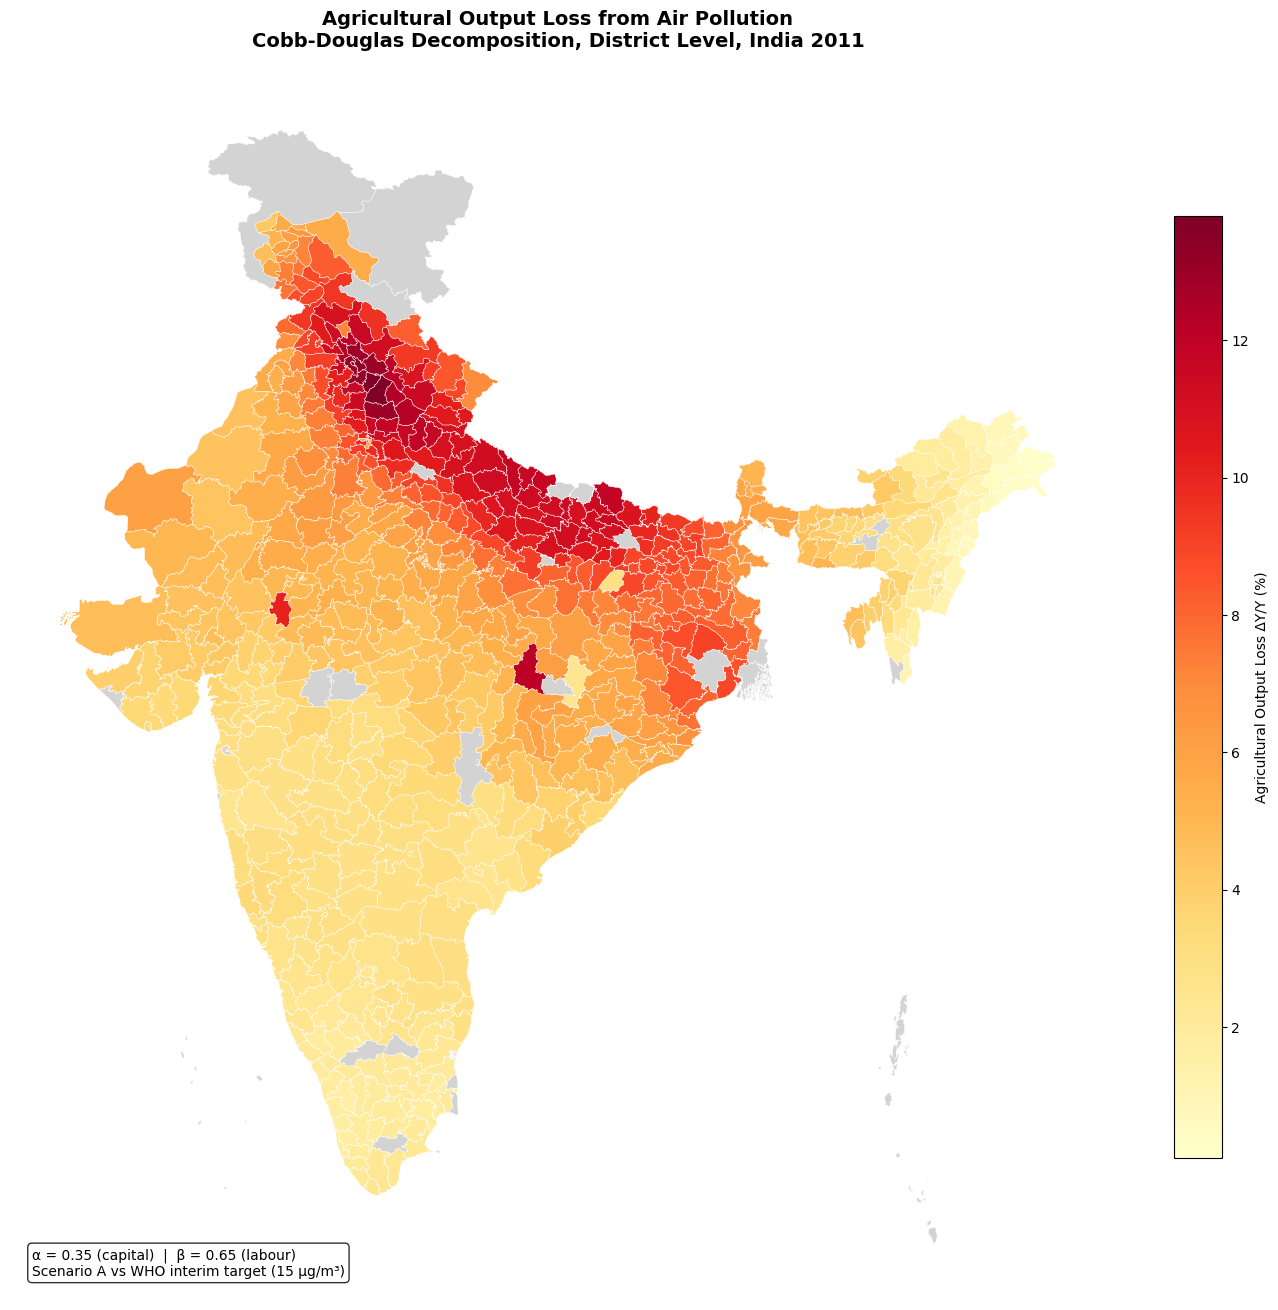


Total estimated agricultural output loss from PM2.5:
$21.69 billion per year

Top 10 districts by absolute dollar loss:
          District            State      PM2.5  ΔY/Y (%)  Loss ($M/yr)
Pashchim Champaran            Bihar 123.099998     11.81         309.9
   Purba Champaran            Bihar 113.900002     10.80         300.2
         Madhubani            Bihar 100.400002      9.33         230.6
        Barddhaman      West Bengal  90.199997      8.21         210.0
       Muzaffarpur            Bihar 106.000000      9.94         200.8
              Gaya            Bihar  96.400002      8.89         183.0
          Bilaspur Himachal Pradesh 125.599998     12.08         181.7
        Samastipur            Bihar  99.599998      9.24         175.2
         Sitamarhi            Bihar 107.400002     10.09         168.6
   Purba Medinipur      West Bengal  96.599998      8.91         164.5


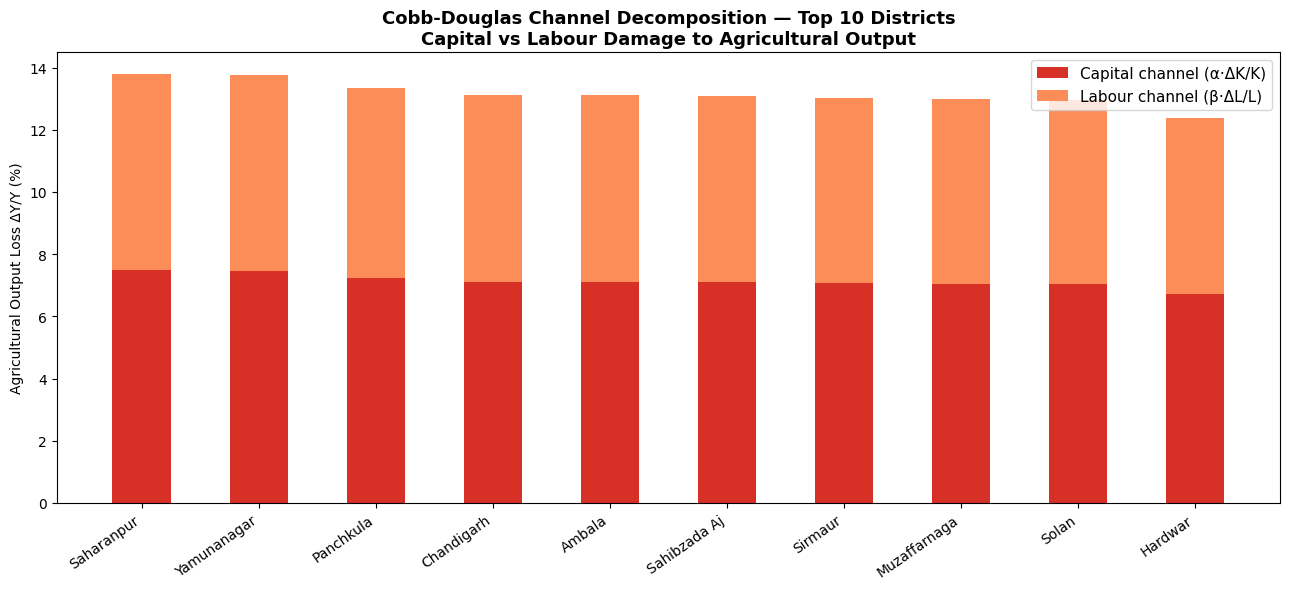

In [6]:
# ── 9. Map of agricultural output loss ───────────────────────────────────────
india_plot = india_clean.merge(
    df[['District_clean', 'dY_agri']], 
    on='District_clean', how='left')

india_plot['dY_pct'] = india_plot['dY_agri'] * 100

fig, ax = plt.subplots(figsize=(14, 16))
india_plot.plot(ax=ax, column='dY_pct', cmap='YlOrRd',
                edgecolor='white', linewidth=0.3,
                legend=True,
                missing_kwds={'color': 'lightgrey'},
                legend_kwds={'label': 'Agricultural Output Loss ΔY/Y (%)',
                             'shrink': 0.6})
ax.set_title("Agricultural Output Loss from Air Pollution\nCobb-Douglas Decomposition, District Level, India 2011",
             fontsize=14, fontweight='bold', pad=20)
ax.axis('off')
ax.text(0.02, 0.02,
        "α = 0.35 (capital)  |  β = 0.65 (labour)\nScenario A vs WHO interim target (15 µg/m³)",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.savefig('cobb_douglas_agri_loss_map.png', dpi=200)
plt.show()

# ── 10. Monetizing the loss ─────────────────────────────────────────────────────
# India agricultural GDP 2011 ≈ $369 billion (World Bank)
# We allocate proportionally by agricultural worker share per district

INDIA_AGRI_GDP_USD = 369e9

total_agri_workers = df['Agricultural_Workers'].sum()
df['Agri_GDP_share'] = df['Agricultural_Workers'] / total_agri_workers
df['Agri_GDP_district'] = df['Agri_GDP_share'] * INDIA_AGRI_GDP_USD

# Dollar loss per district
df['Loss_USD'] = df['dY_agri'] * df['Agri_GDP_district']

total_loss = df['Loss_USD'].sum()
print(f"\nTotal estimated agricultural output loss from PM2.5:")
print(f"${total_loss/1e9:.2f} billion per year")
print(f"\nTop 10 districts by absolute dollar loss:")
top_loss = df[['District_clean', 'ST_NM', 'PM25', 'dY_agri', 'Loss_USD']]\
           .sort_values('Loss_USD', ascending=False).head(10)
top_loss['dY_agri'] = (top_loss['dY_agri']*100).round(2)
top_loss['Loss_USD'] = (top_loss['Loss_USD']/1e6).round(1)
top_loss.columns = ['District', 'State', 'PM2.5', 'ΔY/Y (%)', 'Loss ($M/yr)']
print(top_loss.to_string(index=False))

# ── 11. Channel decomposition chart ──────────────────────────────────────────
top10 = df.nlargest(10, 'dY_agri').copy()
top10['K_loss'] = alpha_agri * top10['dK_agri'] * 100
top10['L_loss'] = beta_agri  * top10['dL_agri'] * 100
labels = top10['District_clean'].str[:12].tolist()

x = np.arange(len(labels))
width = 0.5

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x, top10['K_loss'], width, label='Capital channel (α·ΔK/K)',
       color='#d73027')
ax.bar(x, top10['L_loss'], width, bottom=top10['K_loss'],
       label='Labour channel (β·ΔL/L)', color='#fc8d59')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Agricultural Output Loss ΔY/Y (%)')
ax.set_title('Cobb-Douglas Channel Decomposition — Top 10 Districts\nCapital vs Labour Damage to Agricultural Output',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('channel_decomposition.png', dpi=150)
plt.show()

K rate: 0.001375 per µg/m³
L rate: 0.000625 per µg/m³

Total current agricultural loss:       $22.54B/yr
Remaining if WHO Interim met (15):     $4.91B/yr
Remaining if WHO Strict met (5):       $1.64B/yr
Recovered by meeting Interim (15):     $17.62B/yr
Recovered by meeting Strict (5):       $20.90B/yr


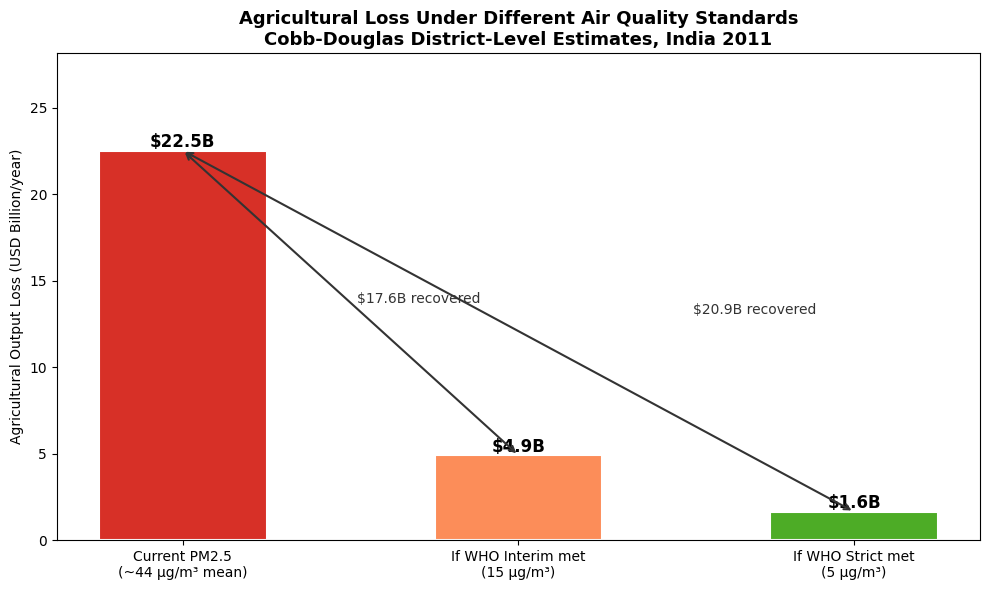

In [14]:
# ── Definitive fix ────────────────────────────────────────────────────────────
# The damage function should be:
# Damage = rate × (actual PM2.5 - counterfactual PM2.5)
# Where counterfactual is what PM2.5 WOULD BE under each standard
# Rate is fixed — calibrated from your presentation values

# At IGP mean of 80 µg/m³: ΔK/K=11%, ΔL/L=5%
# So rate per µg/m³ = damage / PM2.5 level (not excess)
K_RATE_ABS = 0.11 / 80  # per µg/m³ of actual concentration
L_RATE_ABS = 0.05 / 80

print(f"K rate: {K_RATE_ABS:.6f} per µg/m³")
print(f"L rate: {L_RATE_ABS:.6f} per µg/m³")

def compute_loss_v2(counterfactual_pm25):
    """
    Loss = damage at actual PM2.5 minus damage at counterfactual PM2.5
    Counterfactual = what pollution would be if standard were met
    Districts already below counterfactual contribute zero additional gain
    """
    actual_pm25 = df['PM25']
    cf_pm25 = actual_pm25.clip(upper=counterfactual_pm25)

    dK_actual = actual_pm25 * K_RATE_ABS
    dL_actual = actual_pm25 * L_RATE_ABS
    dY_actual = alpha_agri * dK_actual + beta_agri * dL_actual

    dK_cf = cf_pm25 * K_RATE_ABS
    dL_cf = cf_pm25 * L_RATE_ABS
    dY_cf = alpha_agri * dK_cf + beta_agri * dL_cf

    loss_actual = (dY_actual * df['Agri_GDP_district']).sum() / 1e9
    loss_cf     = (dY_cf * df['Agri_GDP_district']).sum() / 1e9
    recovered   = loss_actual - loss_cf

    return loss_actual, loss_cf, recovered

total, remaining_interim, recovered_interim = compute_loss_v2(15)
_,     remaining_strict,  recovered_strict  = compute_loss_v2(5)

print(f"\nTotal current agricultural loss:       ${total:.2f}B/yr")
print(f"Remaining if WHO Interim met (15):     ${remaining_interim:.2f}B/yr")
print(f"Remaining if WHO Strict met (5):       ${remaining_strict:.2f}B/yr")
print(f"Recovered by meeting Interim (15):     ${recovered_interim:.2f}B/yr")
print(f"Recovered by meeting Strict (5):       ${recovered_strict:.2f}B/yr")

# Chart
fig, ax = plt.subplots(figsize=(10, 6))

labels = ['Current PM2.5\n(~44 µg/m³ mean)',
          'If WHO Interim met\n(15 µg/m³)',
          'If WHO Strict met\n(5 µg/m³)']
values = [total, remaining_interim, remaining_strict]
colors = ['#d73027', '#fc8d59', '#4dac26']

bars = ax.bar(labels, values, color=colors,
              edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'${val:.1f}B', ha='center',
            fontweight='bold', fontsize=12)

# Recovery annotations
ax.annotate('', xy=(1, remaining_interim),
            xytext=(0, total),
            arrowprops=dict(arrowstyle='<->', color='#333', lw=1.5))
ax.text(0.52, (total + remaining_interim)/2,
        f'${recovered_interim:.1f}B recovered',
        fontsize=10, color='#333')

ax.annotate('', xy=(2, remaining_strict),
            xytext=(0, total),
            arrowprops=dict(arrowstyle='<->', color='#333', lw=1.5))
ax.text(1.52, (total + remaining_strict)/2 + 1,
        f'${recovered_strict:.1f}B recovered',
        fontsize=10, color='#333')

ax.set_ylabel('Agricultural Output Loss (USD Billion/year)')
ax.set_title('Agricultural Loss Under Different Air Quality Standards\n'
             'Cobb-Douglas District-Level Estimates, India 2011',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, total * 1.25)
plt.tight_layout()
plt.savefig('sensitivity_scenarios.png', dpi=150)
plt.show()

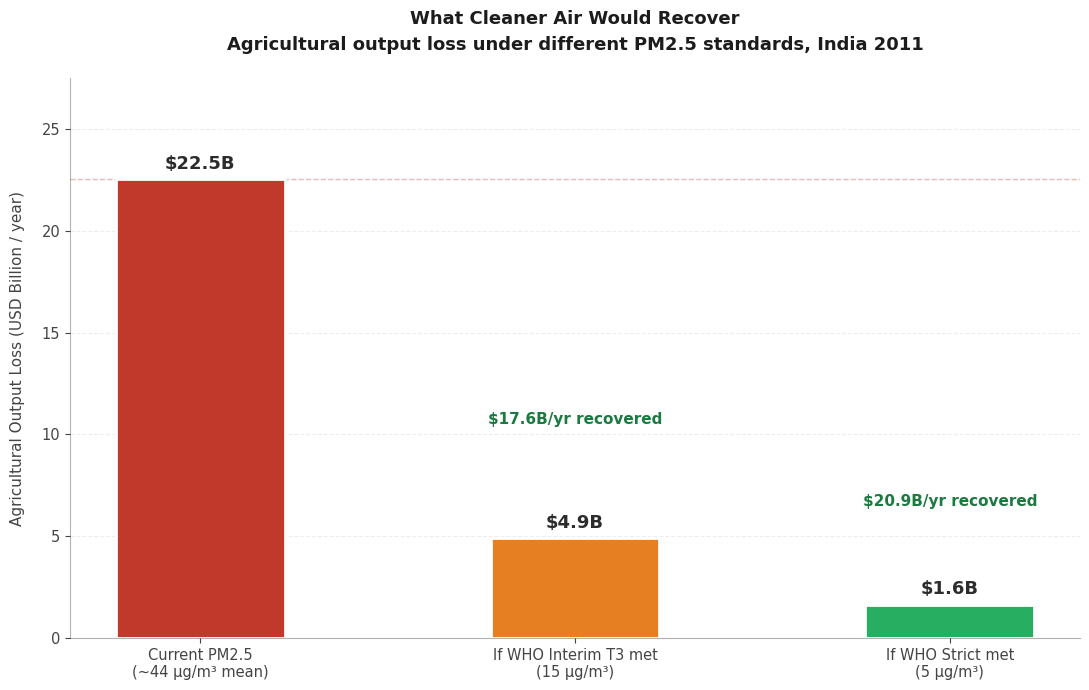

In [17]:
fig, ax = plt.subplots(figsize=(11, 7))

colors = ['#C0392B', '#E67E22', '#27AE60']
values = [total, remaining_interim, remaining_strict]
labels = ['Current PM2.5\n(~44 µg/m³ mean)',
          'If WHO Interim T3 met\n(15 µg/m³)',
          'If WHO Strict met\n(5 µg/m³)']

bars = ax.bar(labels, values, color=colors,
              edgecolor='white', linewidth=2,
              width=0.45, zorder=3)

# Value labels on top of bars
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'${val:.1f}B', ha='center', va='bottom',
            fontweight='bold', fontsize=13, color='#2C2C2C')

# Recovery annotations — moved well above bars, no overlap
ax.text(1.0, 10.5,
        f'${recovered_interim:.1f}B/yr recovered',
        ha='center', fontsize=11, color='#1a7a40', fontweight='bold')

ax.text(2.0, 6.5,
        f'${recovered_strict:.1f}B/yr recovered',
        ha='center', fontsize=11, color='#1a7a40', fontweight='bold')

# Reference dashed line
ax.axhline(y=total, color='#C0392B', linewidth=1,
           linestyle='--', alpha=0.35, zorder=2)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.35,
              color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

# Axis labels
ax.set_ylabel('Agricultural Output Loss (USD Billion / year)',
              fontsize=11, color='#444444', labelpad=12)
ax.set_ylim(0, total * 1.22)
ax.tick_params(axis='both', labelsize=10.5, colors='#444444')

# Title — single clean title, no overlapping subtitle
ax.set_title(
    'What Cleaner Air Would Recover\n'
    'Agricultural output loss under different PM2.5 standards, India 2011',
    fontsize=13, fontweight='bold', color='#1C1C1C', pad=20,
    linespacing=1.6)

plt.tight_layout()
plt.savefig('sensitivity_scenarios.png', dpi=200, bbox_inches='tight')
plt.show()

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# DIRECTION 1: MULTI-SECTOR COBB-DOUGLAS
# Agriculture + Steel + IT Services
# ══════════════════════════════════════════════════════════════════════════════

# ── Sector parameters ──────────────────────────────────
sectors = {
    'Agriculture': {
        'alpha': 0.35, 'beta': 0.65,
        'dK_ref': 0.11, 'dL_ref': 0.05,
        'gdp_usd': 369e9,   # World Bank India agri GDP 2011
        'color': '#2D6A4F'
    },
    'Steel': {
        'alpha': 0.65, 'beta': 0.35,
        'dK_ref': 0.20, 'dL_ref': 0.06,
        'gdp_usd': 45.2e9,  # from your presentation
        'color': '#4A4E69'
    },
    'IT Services': {
        'alpha': 0.15, 'beta': 0.85,
        'dK_ref': 0.03, 'dL_ref': 0.18,
        'gdp_usd': 88e9,    # India IT sector GDP 2011 approx
        'color': '#1F77B4'
    }
}

# ── Reference point ───────────────────────────────────────────────────────────
# At IGP mean PM2.5 = 80 µg/m³
REFERENCE_PM25 = 80.0

# ── Computing losses for each sector ───────────────────────────────────────────
results_sectors = {}

for sector, params in sectors.items():
    K_rate = params['dK_ref'] / REFERENCE_PM25
    L_rate = params['dL_ref'] / REFERENCE_PM25

    # Current loss
    dK = df['PM25'] * K_rate
    dL = df['PM25'] * L_rate
    dY = params['alpha'] * dK + params['beta'] * dL

    # Allocating GDP by population share (proxy for sector presence)
    df[f'gdp_{sector}'] = (df['Population'] / df['Population'].sum()) * params['gdp_usd']
    df[f'loss_{sector}'] = dY * df[f'gdp_{sector}']

    total_loss    = df[f'loss_{sector}'].sum() / 1e9
    K_loss        = (params['alpha'] * dK * df[f'gdp_{sector}']).sum() / 1e9
    L_loss        = (params['beta']  * dL * df[f'gdp_{sector}']).sum() / 1e9

    # Counterfactual: WHO interim 15 µg/m³
    cf_pm25       = df['PM25'].clip(upper=15)
    dK_cf         = cf_pm25 * K_rate
    dL_cf         = cf_pm25 * L_rate
    dY_cf         = params['alpha'] * dK_cf + params['beta'] * dL_cf
    cf_loss       = (dY_cf * df[f'gdp_{sector}']).sum() / 1e9
    recovered     = total_loss - cf_loss

    results_sectors[sector] = {
        'total_loss': total_loss,
        'K_loss': K_loss,
        'L_loss': L_loss,
        'cf_loss': cf_loss,
        'recovered': recovered,
        'dY_mean': dY.mean() * 100
    }

    print(f"\n── {sector} ──────────────────────────────")
    print(f"  Mean ΔY/Y:          {dY.mean()*100:.2f}%")
    print(f"  Total loss:         ${total_loss:.2f}B/yr")
    print(f"  Capital channel:    ${K_loss:.2f}B  ({K_loss/total_loss*100:.1f}%)")
    print(f"  Labour channel:     ${L_loss:.2f}B  ({L_loss/total_loss*100:.1f}%)")
    print(f"  Recoverable (WHO):  ${recovered:.2f}B/yr")

total_all = sum(r['total_loss'] for r in results_sectors.values())
recovered_all = sum(r['recovered'] for r in results_sectors.values())
print(f"\n══ AGGREGATE ═══════════════════════════════")
print(f"  Total loss all sectors:    ${total_all:.2f}B/yr")
print(f"  Recoverable (WHO Interim): ${recovered_all:.2f}B/yr")


── Agriculture ──────────────────────────────
  Mean ΔY/Y:          6.05%
  Total loss:         $23.25B/yr
  Capital channel:    $12.61B  (54.2%)
  Labour channel:     $10.64B  (45.8%)
  Recoverable (WHO):  $18.34B/yr

── Steel ──────────────────────────────
  Mean ΔY/Y:          12.88%
  Total loss:         $6.06B/yr
  Capital channel:    $5.21B  (86.1%)
  Labour channel:     $0.84B  (13.9%)
  Recoverable (WHO):  $4.78B/yr

── IT Services ──────────────────────────────
  Mean ΔY/Y:          13.43%
  Total loss:         $12.30B/yr
  Capital channel:    $0.35B  (2.9%)
  Labour channel:     $11.95B  (97.1%)
  Recoverable (WHO):  $9.70B/yr

══ AGGREGATE ═══════════════════════════════
  Total loss all sectors:    $41.60B/yr
  Recoverable (WHO Interim): $32.81B/yr


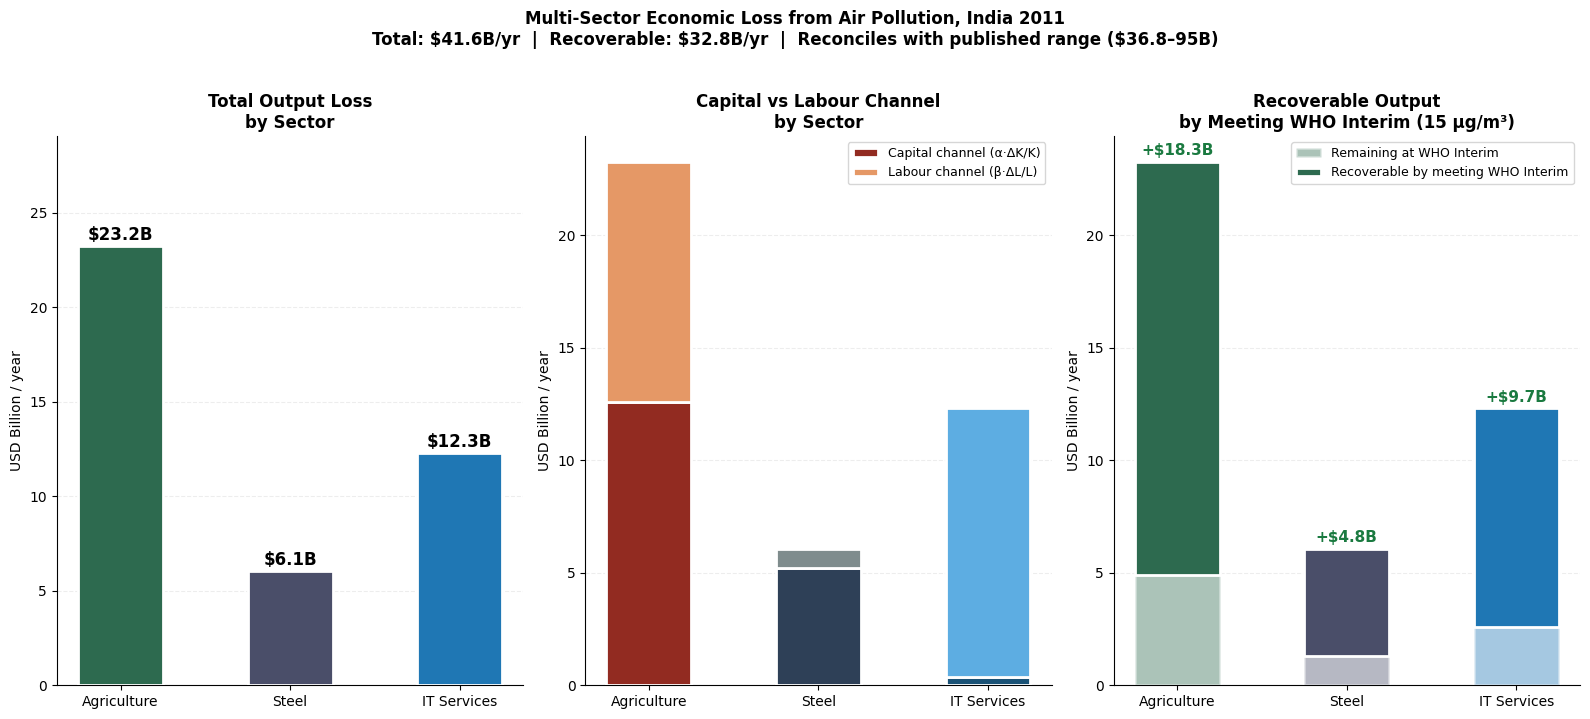

In [20]:
# ── Multi-sector visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

sector_names = list(results_sectors.keys())
colors = [sectors[s]['color'] for s in sector_names]

# ── Chart 1 — Total loss by sector ────────────────────────────────────────────
losses = [results_sectors[s]['total_loss'] for s in sector_names]
bars = axes[0].bar(sector_names, losses, color=colors,
                   edgecolor='white', linewidth=2, width=0.5, zorder=3)

for bar, val in zip(bars, losses):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'${val:.1f}B', ha='center',
                 fontweight='bold', fontsize=12)

axes[0].set_title('Total Output Loss\nby Sector', fontweight='bold', fontsize=12)
axes[0].set_ylabel('USD Billion / year')
axes[0].yaxis.grid(True, linestyle='--', alpha=0.35, color='#CCCCCC')
axes[0].set_axisbelow(True)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_ylim(0, max(losses) * 1.25)

# ── Chart 2 — Capital vs Labour channel stacked ───────────────────────────────
K_losses = [results_sectors[s]['K_loss'] for s in sector_names]
L_losses = [results_sectors[s]['L_loss'] for s in sector_names]
x = range(len(sector_names))

axes[1].bar(sector_names, K_losses, label='Capital channel (α·ΔK/K)',
            color=['#922B21', '#2E4057', '#1a5276'],
            edgecolor='white', linewidth=2, width=0.5, zorder=3)
axes[1].bar(sector_names, L_losses, bottom=K_losses,
            label='Labour channel (β·ΔL/L)',
            color=['#E59866', '#7F8C8D', '#5DADE2'],
            edgecolor='white', linewidth=2, width=0.5, zorder=3)

axes[1].set_title('Capital vs Labour Channel\nby Sector', fontweight='bold', fontsize=12)
axes[1].set_ylabel('USD Billion / year')
axes[1].legend(fontsize=9, loc='upper right')
axes[1].yaxis.grid(True, linestyle='--', alpha=0.35, color='#CCCCCC')
axes[1].set_axisbelow(True)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# ── Chart 3 — Recoverable vs remaining ───────────────────────────────────────
recovered = [results_sectors[s]['recovered'] for s in sector_names]
remaining = [results_sectors[s]['cf_loss'] for s in sector_names]

axes[2].bar(sector_names, remaining, label='Remaining at WHO Interim',
            color=colors, edgecolor='white', linewidth=2,
            width=0.5, alpha=0.4, zorder=3)
axes[2].bar(sector_names, recovered, bottom=remaining,
            label='Recoverable by meeting WHO Interim',
            color=colors, edgecolor='white', linewidth=2,
            width=0.5, zorder=3)

for i, (rec, rem) in enumerate(zip(recovered, remaining)):
    axes[2].text(i, rem + rec + 0.3,
                 f'+${rec:.1f}B', ha='center',
                 fontweight='bold', fontsize=11, color='#1a7a40')

axes[2].set_title('Recoverable Output\nby Meeting WHO Interim (15 µg/m³)',
                  fontweight='bold', fontsize=12)
axes[2].set_ylabel('USD Billion / year')
axes[2].legend(fontsize=9, loc='upper right')
axes[2].yaxis.grid(True, linestyle='--', alpha=0.35, color='#CCCCCC')
axes[2].set_axisbelow(True)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.suptitle(
    f'Multi-Sector Economic Loss from Air Pollution, India 2011\n'
    f'Total: ${total_all:.1f}B/yr  |  Recoverable: ${recovered_all:.1f}B/yr  |  '
    f'Reconciles with published range ($36.8–95B)',
    fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('multisector_loss.png', dpi=200, bbox_inches='tight')
plt.show()

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# DIRECTION 2: DISTRICT-LEVEL PIGOUVIAN TAX CALCULATION
# Optimal tax = marginal damage cost per unit of PM2.5
# ══════════════════════════════════════════════════════════════════════════════

# The Pigouvian tax principle:
# Tax per µg/m³ = total damage caused per µg/m³ of PM2.5 in that district
# We calculate this as: marginal loss / marginal PM2.5

# Total loss per district across all sectors
df['total_loss_district'] = (
    df['loss_Agriculture'] +
    df['loss_Steel'] +
    df['loss_IT Services']
)

# Marginal damage per µg/m³, derivative of loss with respect to PM2.5
# Since loss = rate × PM2.5 × GDP_share, marginal damage = rate × GDP_share
# Summed across all sectors

for sector, params in sectors.items():
    K_rate = params['dK_ref'] / REFERENCE_PM25
    L_rate = params['dL_ref'] / REFERENCE_PM25
    total_rate = params['alpha'] * K_rate + params['beta'] * L_rate
    df[f'marginal_{sector}'] = total_rate * df[f'gdp_{sector}']

df['marginal_damage'] = (
    df['marginal_Agriculture'] +
    df['marginal_Steel'] +
    df['marginal_IT Services']
)

# Pigouvian tax = marginal damage per µg/m³
# Converting to rupees per tonne of PM2.5 equivalent
# 1 µg/m³ annual ambient ≈ 1000 tonnes of PM2.5 emitted (rough atmospheric proxy)
TONNES_PER_UGM3 = 1000

df['pigouvian_tax_per_tonne'] = (df['marginal_damage'] / TONNES_PER_UGM3) * 83  # USD to INR

print("District-level Pigouvian tax estimates:")
print(f"Mean tax:   ₹{df['pigouvian_tax_per_tonne'].mean():,.0f} per tonne PM2.5")
print(f"Max tax:    ₹{df['pigouvian_tax_per_tonne'].max():,.0f} per tonne PM2.5")
print(f"Min tax:    ₹{df['pigouvian_tax_per_tonne'].min():,.0f} per tonne PM2.5")

print("\nTop 10 districts by optimal Pigouvian tax:")
top_tax = df[['District_clean', 'ST_NM', 'PM25',
              'total_loss_district', 'pigouvian_tax_per_tonne']]\
          .sort_values('pigouvian_tax_per_tonne', ascending=False).head(10)
top_tax['total_loss_district'] = (top_tax['total_loss_district']/1e6).round(1)
top_tax['pigouvian_tax_per_tonne'] = top_tax['pigouvian_tax_per_tonne'].round(0).astype(int)
top_tax.columns = ['District', 'State', 'PM2.5', 'Total Loss ($M)', 'Tax (₹/tonne)']
print(top_tax.to_string(index=False))

District-level Pigouvian tax estimates:
Mean tax:   ₹78,203 per tonne PM2.5
Max tax:    ₹454,388 per tonne PM2.5
Min tax:    ₹329 per tonne PM2.5

Top 10 districts by optimal Pigouvian tax:
       District       State     PM2.5  Total Loss ($M)  Tax (₹/tonne)
          Thane Maharashtra 41.799999            228.8         454388
      Bangalore   Karnataka 37.500000            178.6         395285
           Pune Maharashtra 38.799999            181.1         387392
Mumbai Suburban Maharashtra 38.799999            179.7         384415
     Barddhaman West Bengal 90.199997            344.6         317063
      Ahmadabad     Gujarat 52.700001            188.2         296384
    Murshidabad West Bengal 79.800003            280.6         291848
         Jaipur   Rajasthan 73.199997            240.1         272226
         Nashik Maharashtra 42.099998            127.3         250904
          Surat     Gujarat 46.099998            138.8         249841


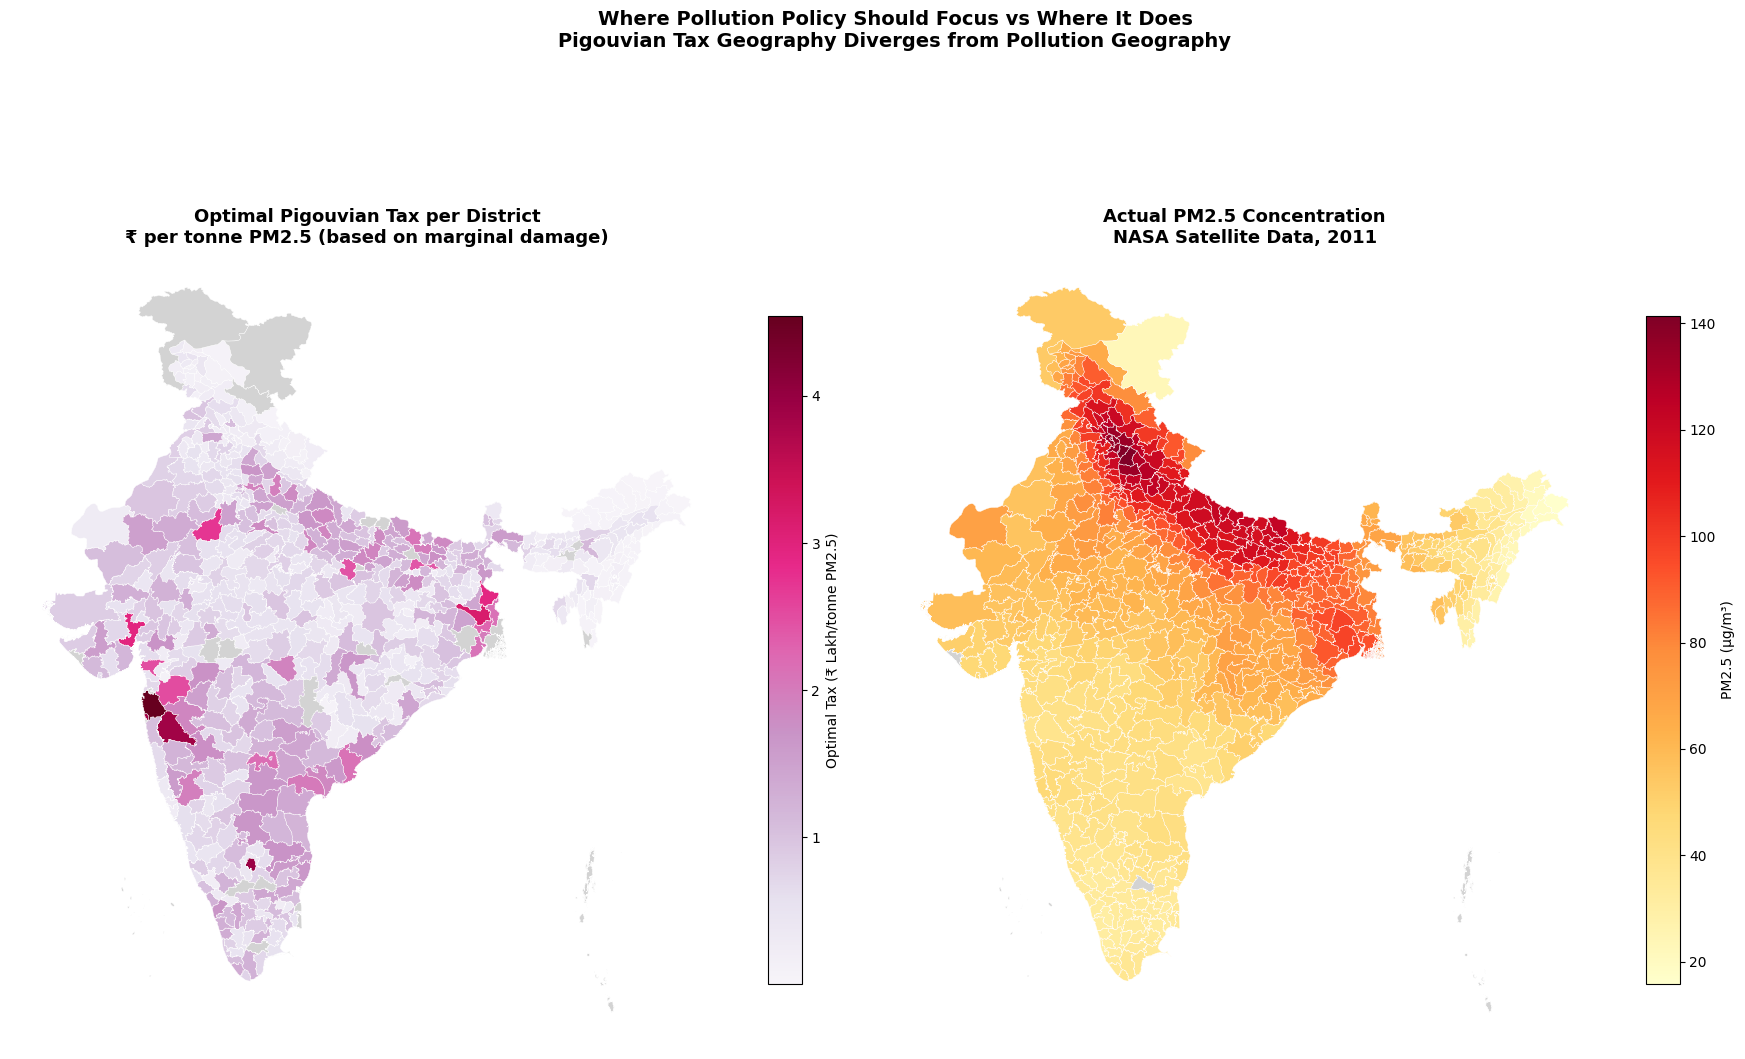

In [22]:
# ── Map the Pigouvian tax ─────────────────────────────────────────────────────
india_tax = india_clean.merge(
    df[['District_clean', 'pigouvian_tax_per_tonne',
        'total_loss_district']],
    on='District_clean', how='left')

india_tax['tax_lakhs'] = india_tax['pigouvian_tax_per_tonne'] / 1e5

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# Map 1: Pigouvian tax
india_tax.plot(ax=axes[0], column='tax_lakhs', cmap='PuRd',
               edgecolor='white', linewidth=0.3, legend=True,
               missing_kwds={'color': 'lightgrey'},
               legend_kwds={'label': 'Optimal Tax (₹ Lakh/tonne PM2.5)',
                            'shrink': 0.6})
axes[0].set_title("Optimal Pigouvian Tax per District\n"
                  "₹ per tonne PM2.5 (based on marginal damage)",
                  fontsize=13, fontweight='bold')
axes[0].axis('off')

# Map 2: PM2.5 for comparison
india_clean.plot(ax=axes[1], column='PM25', cmap='YlOrRd',
                 edgecolor='white', linewidth=0.3, legend=True,
                 missing_kwds={'color': 'lightgrey'},
                 legend_kwds={'label': 'PM2.5 (µg/m³)', 'shrink': 0.6})
axes[1].set_title("Actual PM2.5 Concentration\n"
                  "NASA Satellite Data, 2011",
                  fontsize=13, fontweight='bold')
axes[1].axis('off')

plt.suptitle("Where Pollution Policy Should Focus vs Where It Does\n"
             "Pigouvian Tax Geography Diverges from Pollution Geography",
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('pigouvian_tax_map.png', dpi=200, bbox_inches='tight')
plt.show()

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# DIRECTION 3: TEMPORAL ANALYSIS + NCAP EVALUATION
# PM2.5 trends across 2011, 2015, 2019
# ══════════════════════════════════════════════════════════════════════════════

import os

# ── Loading all three years ──────────────────────────────────────────────────────
base_path = r"C:\Users\Arshia4"

tif_files = {
    2011: os.path.join(base_path, "sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif"),
    2015: os.path.join(base_path, "sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2015.tif"),
    2019: os.path.join(base_path, "sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2019.tif"),
}

def load_india_pm25(tif_path):
    img = Image.open(tif_path)
    img_width, img_height = img.size
    col_start = int((india_lon_min - (-180)) / 360 * img_width)
    col_end   = int((india_lon_max - (-180)) / 360 * img_width)
    row_start = int((90 - india_lat_max) / 180 * img_height)
    row_end   = int((90 - india_lat_min) / 180 * img_height)
    crop      = img.crop((col_start, row_start, col_end, row_end))
    arr       = np.array(crop, dtype=np.float32)
    arr[arr <= 0] = np.nan
    return arr

arrays = {}
for year, path in tif_files.items():
    arrays[year] = load_india_pm25(path)
    print(f"{year}: mean PM2.5 = {np.nanmean(arrays[year]):.2f} µg/m³")

# ── Sampling PM2.5 at each district centroid for each year ─────────────────────
def sample_pm25_array(arr, lon, lat):
    if not (india_lon_min <= lon <= india_lon_max and
            india_lat_min <= lat <= india_lat_max):
        return np.nan
    psl = (india_lon_max - india_lon_min) / arr.shape[1]
    psh = (india_lat_max - india_lat_min) / arr.shape[0]
    col = int((lon - india_lon_min) / psl)
    row = int((india_lat_max - lat) / psh)
    return float(arr[min(row, arr.shape[0]-1), min(col, arr.shape[1]-1)])

for year, arr in arrays.items():
    india_clean[f'PM25_{year}'] = india_clean.apply(
        lambda r: sample_pm25_array(arr, r['centroid_lon'], r['centroid_lat']),
        axis=1)

# ── Building trend dataframe ─────────────────────────────────────────────────────
df_trend = india_clean[['District_clean', 'ST_NM',
                         'PM25_2011', 'PM25_2015', 'PM25_2019']].copy()
df_trend = df_trend.dropna()
df_trend['change_2011_2019'] = df_trend['PM25_2019'] - df_trend['PM25_2011']
df_trend['change_2015_2019'] = df_trend['PM25_2019'] - df_trend['PM25_2015']
df_trend['pct_change']       = (df_trend['change_2011_2019'] /
                                 df_trend['PM25_2011'] * 100)

print(f"\nDistricts with full data: {len(df_trend)}")
print(f"\nIndia mean PM2.5:")
print(f"  2011: {df_trend['PM25_2011'].mean():.2f} µg/m³")
print(f"  2015: {df_trend['PM25_2015'].mean():.2f} µg/m³")
print(f"  2019: {df_trend['PM25_2019'].mean():.2f} µg/m³")
print(f"  Change 2011-2019: {df_trend['change_2011_2019'].mean():.2f} µg/m³")

print(f"\nTop 10 districts with LARGEST pollution increase 2011-2019:")
print(df_trend[['District_clean', 'ST_NM', 'PM25_2011',
                 'PM25_2019', 'change_2011_2019']]\
      .sort_values('change_2011_2019', ascending=False)\
      .head(10).to_string(index=False))

print(f"\nTop 10 districts with LARGEST pollution decrease 2011-2019:")
print(df_trend[['District_clean', 'ST_NM', 'PM25_2011',
                 'PM25_2019', 'change_2011_2019']]\
      .sort_values('change_2011_2019', ascending=True)\
      .head(10).to_string(index=False))

2011: mean PM2.5 = 44.18 µg/m³
2015: mean PM2.5 = 43.85 µg/m³


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Arshia4\\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2019.tif'

In [25]:
import os

# Finding all tif files on your computer
for root, dirs, files in os.walk(r"C:\Users\Arshia4"):
    for file in files:
        if file.endswith('.tif') and 'pm2' in file.lower():
            print(os.path.join(root, file))

C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif
C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2015.tif
C:\Users\Arshia4\Downloads\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011-geotiff\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif


In [26]:
import zipfile

zip_path = r"C:\Users\Arshia4\Downloads\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2019-geotiff.zip"
extract_to = r"C:\Users\Arshia4"

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():
        if file.endswith('.tif'):
            z.extract(file, extract_to)
            print(f"Extracted: {file}")

print("Done!")

Extracted: sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2019.tif
Done!


In [27]:
 # ══════════════════════════════════════════════════════════════════════════════
# FULL TEMPORAL ANALYSIS — 2011, 2015, 2019
# ══════════════════════════════════════════════════════════════════════════════

tif_files = {
    2011: r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif",
    2015: r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2015.tif",
    2019: r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2019.tif",
}

arrays = {}
for year, path in tif_files.items():
    arrays[year] = load_india_pm25(path)
    print(f"{year}: mean PM2.5 = {np.nanmean(arrays[year]):.2f} µg/m³")

# Sample at each district centroid
for year, arr in arrays.items():
    india_clean[f'PM25_{year}'] = india_clean.apply(
        lambda r: sample_pm25_array(arr, r['centroid_lon'], r['centroid_lat']),
        axis=1)

# Build trend dataframe
df_trend = india_clean[['District_clean', 'ST_NM',
                         'PM25_2011', 'PM25_2015', 'PM25_2019']].copy()
df_trend = df_trend.dropna()

df_trend['change_11_15'] = df_trend['PM25_2015'] - df_trend['PM25_2011']
df_trend['change_15_19'] = df_trend['PM25_2019'] - df_trend['PM25_2015']
df_trend['change_11_19'] = df_trend['PM25_2019'] - df_trend['PM25_2011']
df_trend['pct_change']   = (df_trend['change_11_19'] /
                             df_trend['PM25_2011'] * 100)

print(f"\nDistricts with full data: {len(df_trend)}")
print(f"\nIndia national mean PM2.5:")
print(f"  2011: {df_trend['PM25_2011'].mean():.2f} µg/m³")
print(f"  2015: {df_trend['PM25_2015'].mean():.2f} µg/m³")
print(f"  2019: {df_trend['PM25_2019'].mean():.2f} µg/m³")
print(f"  Change 2011-2019: {df_trend['change_11_19'].mean():.2f} µg/m³")
print(f"  % change 2011-2019: {df_trend['pct_change'].mean():.1f}%")

print(f"\nDistricts improved 2011-2019: "
      f"{(df_trend['change_11_19'] < 0).sum()} / {len(df_trend)}")
print(f"Districts worsened 2011-2019: "
      f"{(df_trend['change_11_19'] > 0).sum()} / {len(df_trend)}")

print(f"\nTop 10 most improved 2011-2019:")
print(df_trend[['District_clean', 'ST_NM',
                 'PM25_2011', 'PM25_2019', 'change_11_19']]\
      .sort_values('change_11_19').head(10).to_string(index=False))

print(f"\nTop 10 most worsened 2011-2019:")
print(df_trend[['District_clean', 'ST_NM',
                 'PM25_2011', 'PM25_2019', 'change_11_19']]\
      .sort_values('change_11_19', ascending=False).head(10).to_string(index=False))

2011: mean PM2.5 = 44.18 µg/m³
2015: mean PM2.5 = 43.85 µg/m³
2019: mean PM2.5 = 46.12 µg/m³


NameError: name 'sample_pm25_array' is not defined

In [28]:
import os

for root, dirs, files in os.walk(r"C:\Users\Arshia4"):
    for file in files:
        if file.endswith('.tif') and '201' in file:
            print(os.path.join(root, file))

C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif
C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2015.tif
C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2019.tif
C:\Users\Arshia4\Downloads\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011-geotiff\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif


In [3]:
from PIL import Image
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
Image.MAX_IMAGE_PIXELS = None

india_lon_min, india_lon_max = 68.0, 97.5
india_lat_min, india_lat_max = 8.0, 37.5

def load_india_pm25(tif_path):
    img = Image.open(tif_path)
    w, h = img.size
    col_start = int((india_lon_min + 180) / 360 * w)
    col_end   = int((india_lon_max + 180) / 360 * w)
    row_start = int((90 - india_lat_max) / 180 * h)
    row_end   = int((90 - india_lat_min) / 180 * h)
    arr = np.array(img.crop((col_start, row_start, col_end, row_end)), dtype=np.float32)
    arr[arr <= 0] = np.nan
    return arr

def sample(arr, lon, lat):
    if not (india_lon_min <= lon <= india_lon_max and india_lat_min <= lat <= india_lat_max):
        return np.nan
    col = int((lon - india_lon_min) / (india_lon_max - india_lon_min) * arr.shape[1])
    row = int((india_lat_max - lat) / (india_lat_max - india_lat_min) * arr.shape[0])
    return float(arr[min(row, arr.shape[0]-1), min(col, arr.shape[1]-1)])

tif_files = {
    2011: r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif",
    2015: r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2015.tif",
    2019: r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2019.tif",
}

arrays = {}
for year, path in tif_files.items():
    arrays[year] = load_india_pm25(path)
    print(str(year) + ": mean PM2.5 = " + str(round(float(np.nanmean(arrays[year])), 2)) + " ug/m3")

india = gpd.read_file("https://github.com/datameet/maps/raw/master/Districts/Census_2011/2011_Dist.shp")
india['District_clean'] = india['DISTRICT'].str.strip().str.title()
india['centroid_lon']   = india.geometry.centroid.x
india['centroid_lat']   = india.geometry.centroid.y

for year, arr in arrays.items():
    india['PM25_' + str(year)] = india.apply(
        lambda r: sample(arr, r['centroid_lon'], r['centroid_lat']), axis=1)
    print("Sampled " + str(year) + ": " + str(india['PM25_' + str(year)].notna().sum()) + " districts")

df_trend = india[['District_clean', 'ST_NM',
                   'PM25_2011', 'PM25_2015', 'PM25_2019']].copy().dropna()

df_trend['change_11_15'] = df_trend['PM25_2015'] - df_trend['PM25_2011']
df_trend['change_15_19'] = df_trend['PM25_2019'] - df_trend['PM25_2015']
df_trend['change_11_19'] = df_trend['PM25_2019'] - df_trend['PM25_2011']
df_trend['pct_change']   = df_trend['change_11_19'] / df_trend['PM25_2011'] * 100

print("Districts with full data: " + str(len(df_trend)))
print("India national mean PM2.5:")
print("  2011: " + str(round(df_trend['PM25_2011'].mean(), 2)) + " ug/m3")
print("  2015: " + str(round(df_trend['PM25_2015'].mean(), 2)) + " ug/m3")
print("  2019: " + str(round(df_trend['PM25_2019'].mean(), 2)) + " ug/m3")
print("  Change 2011-2019: " + str(round(df_trend['change_11_19'].mean(), 2)) + " ug/m3")
print("  Pct change: " + str(round(df_trend['pct_change'].mean(), 1)) + "%")
print("Improved: " + str((df_trend['change_11_19'] < 0).sum()) + " districts")
print("Worsened: " + str((df_trend['change_11_19'] > 0).sum()) + " districts")

print("Top 10 most improved 2011-2019:")
print(df_trend[['District_clean', 'ST_NM', 'PM25_2011', 'PM25_2019', 'change_11_19']]\
      .sort_values('change_11_19').head(10).to_string(index=False))

print("Top 10 most worsened 2011-2019:")
print(df_trend[['District_clean', 'ST_NM', 'PM25_2011', 'PM25_2019', 'change_11_19']]\
      .sort_values('change_11_19', ascending=False).head(10).to_string(index=False))

2011: mean PM2.5 = 44.18 ug/m3
2015: mean PM2.5 = 43.85 ug/m3
2019: mean PM2.5 = 46.12 ug/m3
Sampled 2011: 634 districts
Sampled 2015: 634 districts
Sampled 2019: 634 districts
Districts with full data: 634
India national mean PM2.5:
  2011: 67.96 ug/m3
  2015: 64.99 ug/m3
  2019: 69.17 ug/m3
  Change 2011-2019: 1.21 ug/m3
  Pct change: 4.2%
Improved: 244 districts
Worsened: 383 districts
Top 10 most improved 2011-2019:
District_clean            ST_NM  PM25_2011  PM25_2019  change_11_19
    Saharanpur    Uttar Pradesh 141.399994 111.300003    -30.099991
   Yamunanagar          Haryana 140.899994 111.000000    -29.899994
       Sirmaur Himachal Pradesh 134.300003 105.400002    -28.900002
     Panchkula          Haryana 137.100006 110.699997    -26.400009
         Solan Himachal Pradesh 133.699997 109.000000    -24.699997
    Uttarkashi      Uttarakhand 100.400002  77.099998    -23.300003
    Chandigarh       Chandigarh 135.199997 112.400002    -22.799995
        Ambala          Haryana 

C:\Users\Arshia4\AppData\Local\Temp\ipykernel_23896\3763364665.py:42: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india['centroid_lon']   = india.geometry.centroid.x
C:\Users\Arshia4\AppData\Local\Temp\ipykernel_23896\3763364665.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  india['centroid_lat']   = india.geometry.centroid.y


In [4]:
import os

files = {
    2011: r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2011.tif",
    2015: r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2015.tif",
    2019: r"C:\Users\Arshia4\sdei-global-annual-gwr-pm2-5-modis-misr-seawifs-aod-v4-gl-03-2019.tif",
}

for year, path in files.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) / 1e6 if exists else 0
    print(str(year) + " — exists: " + str(exists) + " — size: " + str(round(size, 1)) + " MB")

2011 — exists: True — size: 1811.8 MB
2015 — exists: True — size: 1811.8 MB
2019 — exists: True — size: 1812.0 MB


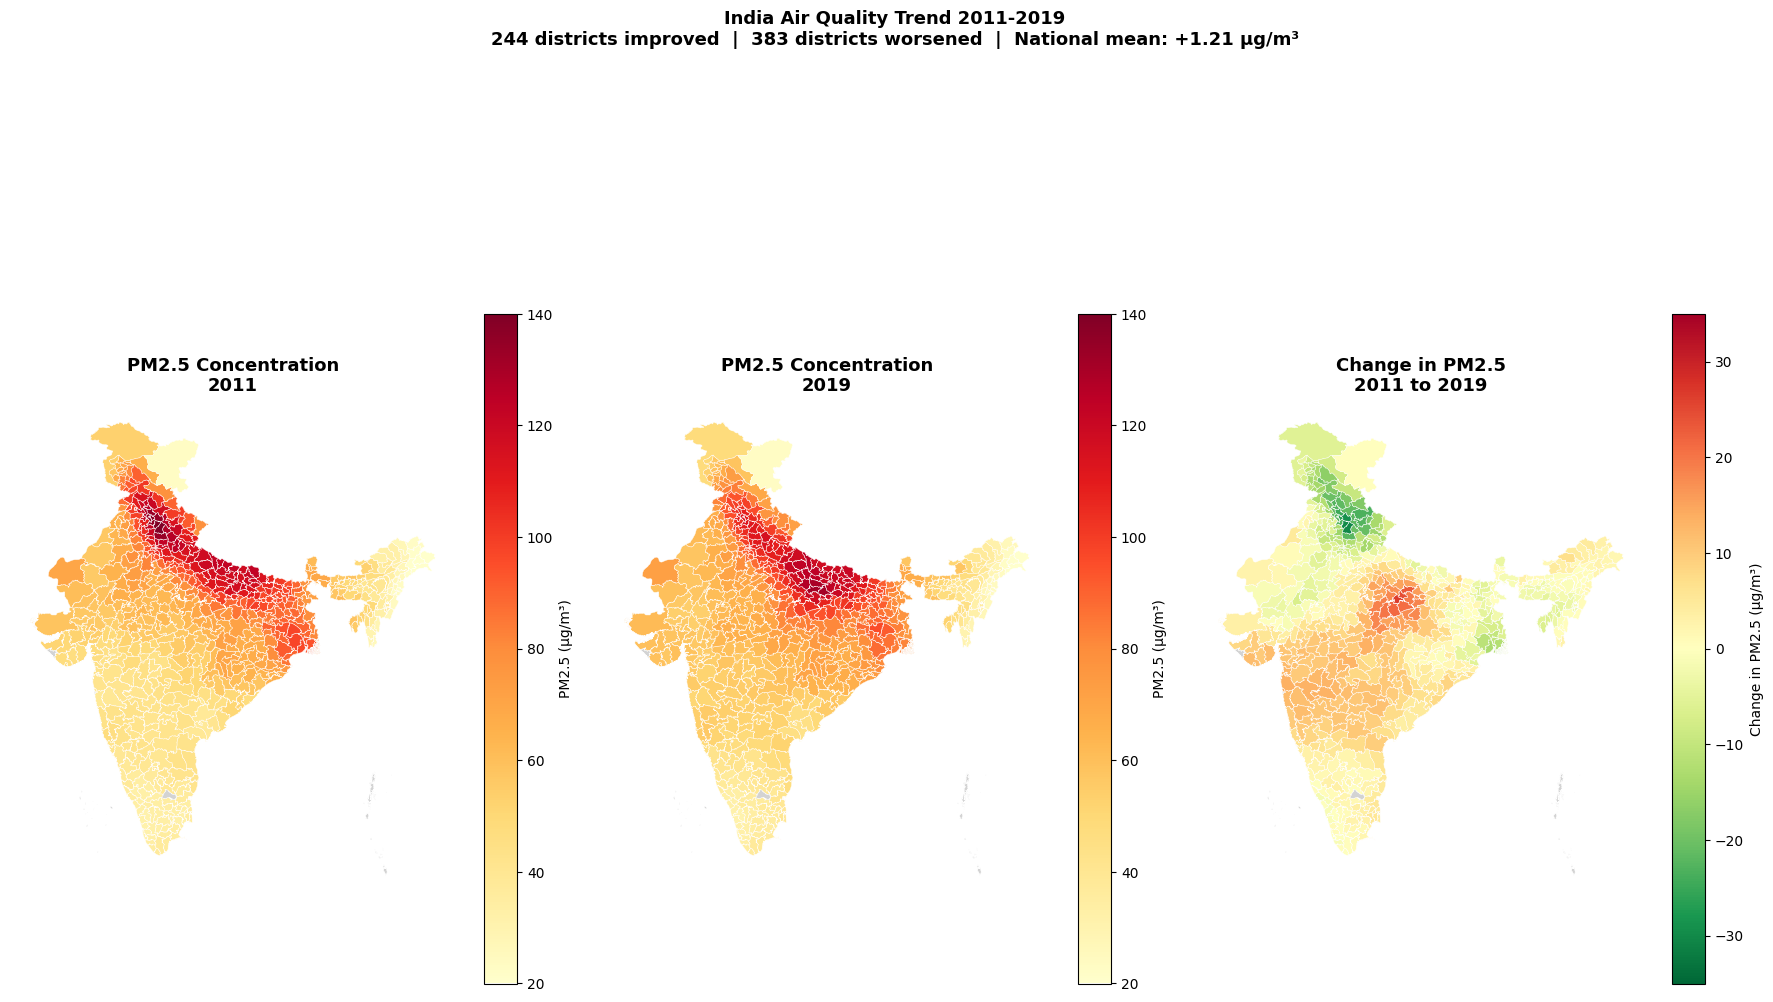

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 12))

# ── Map 1 — PM2.5 2011 ────────────────────────────────────────────────────────
india.plot(ax=axes[0], column='PM25_2011', cmap='YlOrRd',
           edgecolor='white', linewidth=0.3, legend=True,
           vmin=20, vmax=140,
           missing_kwds={'color': 'lightgrey'},
           legend_kwds={'label': 'PM2.5 (µg/m³)', 'shrink': 0.6})
axes[0].set_title("PM2.5 Concentration\n2011", fontsize=13, fontweight='bold')
axes[0].axis('off')

# ── Map 2 — PM2.5 2019 ────────────────────────────────────────────────────────
india.plot(ax=axes[1], column='PM25_2019', cmap='YlOrRd',
           edgecolor='white', linewidth=0.3, legend=True,
           vmin=20, vmax=140,
           missing_kwds={'color': 'lightgrey'},
           legend_kwds={'label': 'PM2.5 (µg/m³)', 'shrink': 0.6})
axes[1].set_title("PM2.5 Concentration\n2019", fontsize=13, fontweight='bold')
axes[1].axis('off')

# ── Map 3 — Change 2011 to 2019 ───────────────────────────────────────────────
india['change_11_19'] = india['PM25_2019'] - india['PM25_2011']
india.plot(ax=axes[2], column='change_11_19', cmap='RdYlGn_r',
           edgecolor='white', linewidth=0.3, legend=True,
           vmin=-35, vmax=35,
           missing_kwds={'color': 'lightgrey'},
           legend_kwds={'label': 'Change in PM2.5 (µg/m³)', 'shrink': 0.6})
axes[2].set_title("Change in PM2.5\n2011 to 2019", fontsize=13, fontweight='bold')
axes[2].axis('off')

plt.suptitle(
    "India Air Quality Trend 2011-2019\n"
    "244 districts improved  |  383 districts worsened  |  "
    "National mean: +1.21 µg/m³",
    fontsize=13, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('temporal_trend_maps.png', dpi=200, bbox_inches='tight')
plt.show()

C:\Users\Arshia4\AppData\Local\Temp\ipykernel_23896\167782380.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_census['District_clean'] = df_census['District name'].str.strip().str.title()


Total economic loss (all sectors):
  2011: $41.6B/yr
  2015: $40.32B/yr
  2019: $43.09B/yr
  Additional loss 2011-2019: $1.49B/yr
  % increase in economic damage: 3.6%


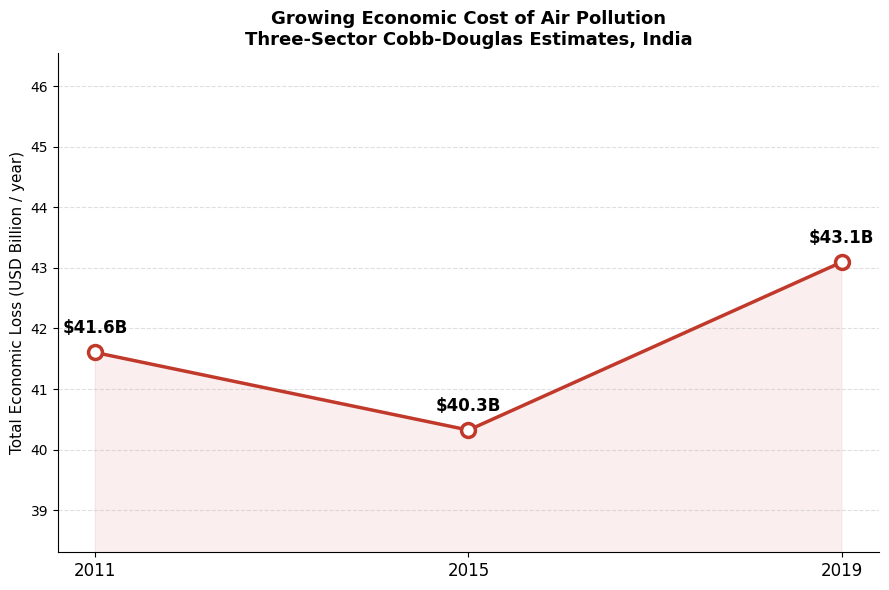

In [6]:
# ── Cost of worsening — 2011 vs 2019 Cobb-Douglas comparison ─────────────────

# Sector parameters
sectors = {
    'Agriculture': {'alpha': 0.35, 'beta': 0.65, 'dK': 0.11,
                    'dL': 0.05, 'gdp': 369e9},
    'Steel':       {'alpha': 0.65, 'beta': 0.35, 'dK': 0.20,
                    'dL': 0.06, 'gdp': 45.2e9},
    'IT Services': {'alpha': 0.15, 'beta': 0.85, 'dK': 0.03,
                    'dL': 0.18, 'gdp': 88e9},
}

REFERENCE_PM25 = 80.0

def compute_total_loss(pm25_series, pop_series, total_pop):
    total = 0
    for s, p in sectors.items():
        K_rate = p['dK'] / REFERENCE_PM25
        L_rate = p['dL'] / REFERENCE_PM25
        dY     = p['alpha'] * pm25_series * K_rate + p['beta'] * pm25_series * L_rate
        gdp_share = pop_series / total_pop
        total += (dY * gdp_share * p['gdp']).sum()
    return total / 1e9

# Merge population into trend dataframe
df_census = pd.read_csv("https://raw.githubusercontent.com/nishusharma1608/India-Census-2011-Analysis/master/india-districts-census-2011.csv")
df_census['District_clean'] = df_census['District name'].str.strip().str.title()

df_t = df_trend.merge(df_census[['District_clean', 'Population']],
                      on='District_clean', how='inner').dropna()

total_pop = df_t['Population'].sum()

loss_2011 = compute_total_loss(df_t['PM25_2011'], df_t['Population'], total_pop)
loss_2015 = compute_total_loss(df_t['PM25_2015'], df_t['Population'], total_pop)
loss_2019 = compute_total_loss(df_t['PM25_2019'], df_t['Population'], total_pop)

print("Total economic loss (all sectors):")
print("  2011: $" + str(round(loss_2011, 2)) + "B/yr")
print("  2015: $" + str(round(loss_2015, 2)) + "B/yr")
print("  2019: $" + str(round(loss_2019, 2)) + "B/yr")
print("  Additional loss 2011-2019: $" + str(round(loss_2019 - loss_2011, 2)) + "B/yr")
print("  % increase in economic damage: " +
      str(round((loss_2019 - loss_2011) / loss_2011 * 100, 1)) + "%")

# Chart
years  = [2011, 2015, 2019]
losses = [loss_2011, loss_2015, loss_2019]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(years, losses, 'o-', color='#C0392B', linewidth=2.5,
        markersize=10, markerfacecolor='white', markeredgewidth=2.5)

for yr, loss in zip(years, losses):
    ax.annotate("$" + str(round(loss, 1)) + "B",
                xy=(yr, loss), xytext=(0, 14),
                textcoords='offset points', ha='center',
                fontweight='bold', fontsize=12)

ax.fill_between(years, losses, alpha=0.08, color='#C0392B')
ax.set_xticks(years)
ax.set_xticklabels(['2011', '2015', '2019'], fontsize=12)
ax.set_ylabel('Total Economic Loss (USD Billion / year)', fontsize=11)
ax.set_title('Growing Economic Cost of Air Pollution\n'
             'Three-Sector Cobb-Douglas Estimates, India',
             fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(min(losses) * 0.95, max(losses) * 1.08)
plt.tight_layout()
plt.savefig('loss_trend.png', dpi=200, bbox_inches='tight')
plt.show()